In [3]:
# ---------- Cell 1 : 基础配置与依赖导入 ----------
import os
import re
import random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
import sys
import pykeen.pipeline as pk_pipeline

# ========= 1. 基础配置 ========= #
INPUT_CSV = "PPMI诊断.csv"
PREFIX = "distmult_PPMI" 

# 严格保持原来的32维
EMBED_DIM = 32
SEED = 2025

# 剔除元数据、目标标签与个别冗余文本特征
EXCLUDE_COLS = {
    'Image Data ID', 'Subject', 'Visit', 'visit_month', 
    'Description', 'Type', 'Acq Date', 'Format', 'Group', 
    'upd2hy_hoehn_and_yahr_stage'
}

# 中间训练用的 TSV 文件
TRIPLE_TRAIN = f"train_{PREFIX}.tsv"
TRIPLE_VALID = f"valid_{PREFIX}.tsv"
TRIPLE_TEST = f"test_{PREFIX}.tsv"

# 最终输出的模型和映射文件名称
ENTITY2ID_PATH = "CustomKG-PPMI.txt"
REL2ID_PATH = "relation2id_CustomKG-PPMI.txt" 
EMB_PATH = "CustomKG-PPMI.npy"

# 固定随机种子
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Cell 1: 基础配置与依赖加载完成。输出文件已设定为 CustomKG-PPMI 系列。")

✅ Cell 1: 基础配置与依赖加载完成。输出文件已设定为 CustomKG-PPMI 系列。


In [4]:
# ---------- Cell 2 : 辅助函数与特征图谱构建 ----------
def sanitize(text: str) -> str:
    return re.sub(r"\s+", "_", str(text).strip())

def age_bin(age):
    try:
        a = float(age)
    except:
        return "age_unknown"
    lo = int(a // 10 * 10)
    return f"age_{lo}_{lo + 9}"

def get_triples_for_patient(row: pd.Series):
    """
    生成纯特征三元组，防止数据泄露，同时提取 EHR 与 PHE 模块特征
    """
    h = sanitize(row['Subject'])
    feature_triples = []

    # 1. 处理 EHR 基础人口学特征
    if "Sex" in row and pd.notna(row["Sex"]):
        feature_triples.append((h, "has_sex", sanitize(row["Sex"])))
    if "Age" in row and pd.notna(row["Age"]):
        feature_triples.append((h, "has_age_bin", age_bin(row["Age"])))

    # 2. 处理剩余的 EHR 与 PHE 特征
    # 允许直接保留的特殊 EHR 与并发症特征（不带 code_ 也能保留）
    allowed_upd2 = [
        'upd23a_medication_for_pd', 
        'upd23b_clinical_state_on_medication', 
        'upd2da_dyskinesias_during_exam', 
        'upd2db_movements_interfere_with_ratings'
    ]

    for col in row.index:
        # 排除已经处理过的基础特征
        if col in ['Age', 'Sex', 'Subject']:
            continue

        # 过滤元数据与疾病分组
        if col in EXCLUDE_COLS:
            continue

        # 过滤 34 个主观冗余文本特征
        # 逻辑：如果前缀是 upd2，并且不在允许列表中，且没有 code_ 前缀，则过滤掉
        if col.startswith('upd2') and col not in allowed_upd2:
            continue

        v = row[col]
        if pd.isna(v) or str(v).strip() in ("", "nan"):
            continue

        col_name = sanitize(col)
        val_str = sanitize(v)
        feature_triples.append((h, f"has_{col_name}", val_str))

    return feature_triples

print(f">> Loading data from {INPUT_CSV} ...")
if not Path(INPUT_CSV).exists():
    print(f"Error: File not found {INPUT_CSV}")
else:
    df = pd.read_csv(INPUT_CSV)
    
    if 'Subject' not in df.columns:
        raise ValueError(f"{INPUT_CSV} 中缺少 'Subject' 列，无法提取ID")
    
    all_triples = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="   Parsing Data"):
        feats = get_triples_for_patient(row)
        all_triples.extend(feats)
        
    print(f"\n✅ Cell 2: 数据解析完成。共提取到无监督特征三元组总数: {len(all_triples)}")

>> Loading data from PPMI诊断.csv ...


   Parsing Data: 100%|██████████| 409/409 [00:00<00:00, 5108.93it/s]


✅ Cell 2: 数据解析完成。共提取到无监督特征三元组总数: 16410


In [5]:
# ---------- Cell 3 : 随机切分三元组与保存中间文件 ----------
# 随机打乱三元组
random.shuffle(all_triples)

n_total = len(all_triples)
n_test = int(n_total * 0.10)
n_valid = int(n_total * 0.10)

final_test = all_triples[:n_test]
final_valid = all_triples[n_test:n_test + n_valid]
final_train = all_triples[n_test + n_valid:]

print(f"\n>> Triples Stats:")
print(f"   Train Triples: {len(final_train):,}")
print(f"   Valid Triples: {len(final_valid):,}")
print(f"   Test  Triples: {len(final_test):,}")

# 保存为 PyKeen 需要的 TSV 格式
def save_tsv(path, triples):
    with open(path, "w", encoding="utf-8") as f:
        for h, r, t in triples: 
            f.write(f"{h}\t{r}\t{t}\n")

save_tsv(TRIPLE_TRAIN, final_train)
save_tsv(TRIPLE_VALID, final_valid)
save_tsv(TRIPLE_TEST, final_test)

print("\n✅ Cell 3: 数据集切分与 TSV 保存完成，准备进入模型训练。")


>> Triples Stats:
   Train Triples: 13,128
   Valid Triples: 1,641
   Test  Triples: 1,641

✅ Cell 3: 数据集切分与 TSV 保存完成，准备进入模型训练。


In [9]:
# ---------- Cell 4 : PyKeen 训练、提取 Loss、评估指标与保存 ----------
import os
import torch
import numpy as np

print("\n>> Starting DistMult training ...")

# 自动检测设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device: {device}")

# 启动 PyKeen 训练管线 (严格使用已设定的 32 维)
result = pk_pipeline.pipeline(
    model="DistMult",
    training=TRIPLE_TRAIN,
    validation=TRIPLE_VALID,
    testing=TRIPLE_TEST,
    model_kwargs=dict(embedding_dim=EMBED_DIM),
    training_kwargs=dict(num_epochs=100, batch_size=256),
    stopper="early",
    stopper_kwargs=dict(frequency=5, patience=10, relative_delta=0.002),
    evaluator_kwargs=dict(filtered=True, batch_size=8),
    negative_sampler="basic",
    random_seed=SEED,
    device=device,
    training_loop="SLCWA",
)

print("\n>> Training Finished.")

# ================= 提取训练 Loss =================
train_losses = result.training_loop.losses_per_epochs
np.save("CustomKG-PPMI-Losses.npy", train_losses)

# ================= 提取测试集标准评估指标 (KGE 领域标准) =================
# 获取 MRR 和 Hits@K
mrr = result.metric_results.get_metric('mrr')
hits_10 = result.metric_results.get_metric('hits@10')
hits_3 = result.metric_results.get_metric('hits@3')
hits_1 = result.metric_results.get_metric('hits@1')

test_metrics = {'MRR': mrr, 'Hits@10': hits_10, 'Hits@3': hits_3, 'Hits@1': hits_1}
np.save("CustomKG-PPMI-TestMetrics.npy", test_metrics)

print("\n==========================================")
print("     CustomKG-PPMI 测试集预测指标评估")
print("==========================================")
print(f"MRR (Mean Reciprocal Rank): {mrr:.4f}")
print(f"Hits@10: {hits_10:.4f}")
print(f"Hits@3:  {hits_3:.4f}")
print(f"Hits@1:  {hits_1:.4f}")
print("==========================================")

# ================= 保存嵌入和映射字典 =================
model = result.model
entity_embs = model.entity_representations[0]().cpu().detach().numpy()

np.save(EMB_PATH, entity_embs)

with open(ENTITY2ID_PATH, "w", encoding="utf-8") as f:
    for e, i in result.training.entity_to_id.items():
        f.write(f"{e}\t{i}\n")

with open(REL2ID_PATH, "w", encoding="utf-8") as f:
    for r, i in result.training.relation_to_id.items():
        f.write(f"{r}\t{i}\n")

print(f"\n✅ 嵌入与映射文件均已严格保存！")

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: C:\Users\HP\.data\pykeen\checkpoints\best-model-weights-9f58a01d-486f-45d0-80d2-245920ec9125.pt



>> Starting DistMult training ...
   Using device: cpu


d:\Anaconda\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/34.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/34.0 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.23s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 100. The best result 0.7881640887693342 occurred at epoch 50.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from C:\Users\HP\.data\pykeen\checkpoints\best-model-weights-9f58a01d-486f-45d0-80d2-245920ec9125.pt


Evaluating on cpu:   0%|          | 0.00/1.52k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.22s seconds



>> Training Finished.

     CustomKG-PPMI 测试集预测指标评估
MRR (Mean Reciprocal Rank): 0.4453
Hits@10: 0.8181
Hits@3:  0.4746
Hits@1:  0.2732

✅ 嵌入与映射文件均已严格保存！


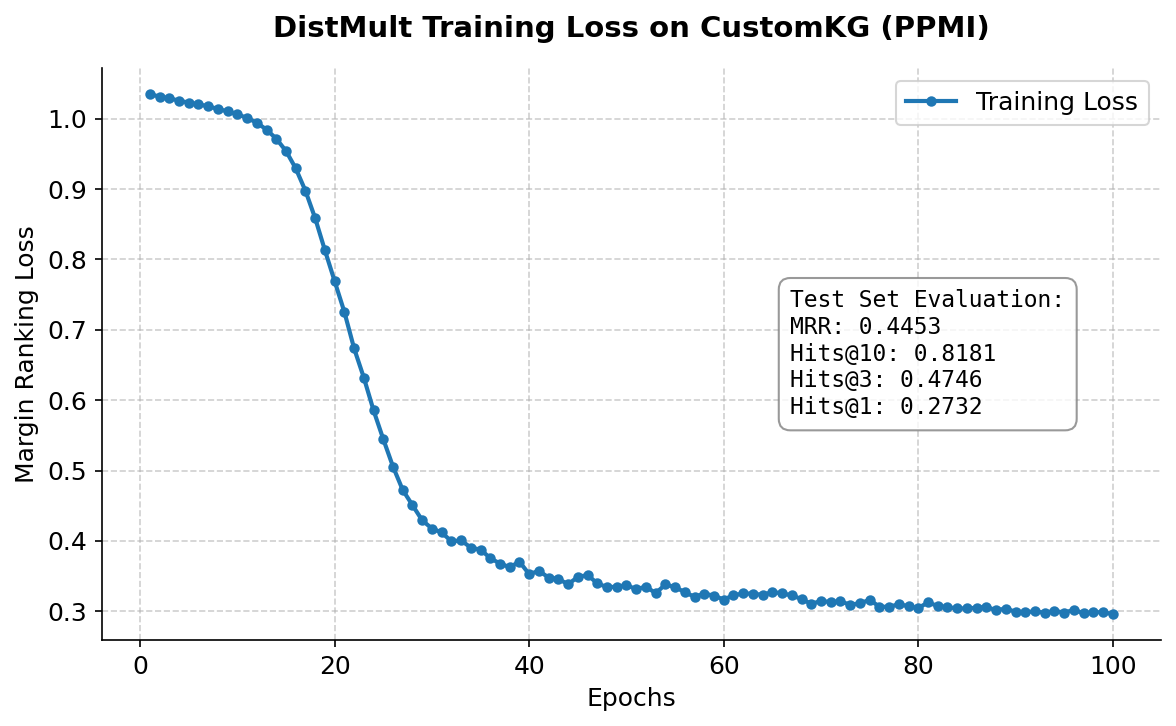

✅ Loss 曲线绘制完成！图表已包含测试集指标，高清图像已保存至: CustomKG-PPMI-LossCurve-with-Metrics.png


In [12]:
# ---------- Cell 5 : 绘制并保存训练 Loss 曲线 (带测试指标) ----------
import matplotlib.pyplot as plt
import numpy as np

# 读取 Loss 数据和测试指标
try:
    train_losses = np.load("CustomKG-PPMI-Losses.npy")
    test_metrics = np.load("CustomKG-PPMI-TestMetrics.npy", allow_pickle=True).item()
except FileNotFoundError:
    print("❌ 找不到文件，请确保 Cell 4 已成功运行。")
    train_losses = []

if len(train_losses) > 0:
    plt.rcParams.update({'font.size': 12})
    
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    
    # 绘制训练 Loss 曲线
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, color='#1f77b4', linewidth=2, linestyle='-', marker='o', markersize=4, label='Training Loss')
    
    ax.set_title('DistMult Training Loss on CustomKG (PPMI)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Margin Ranking Loss', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right')
    
    # 在图表中嵌入测试集评估指标 (画龙点睛之笔)
    metrics_text = (
        "Test Set Evaluation:\n"
        f"MRR: {test_metrics['MRR']:.4f}\n"
        f"Hits@10: {test_metrics['Hits@10']:.4f}\n"
        f"Hits@3: {test_metrics['Hits@3']:.4f}\n"
        f"Hits@1: {test_metrics['Hits@1']:.4f}"
    )
    
    # 将指标文本框放置在图表内部（中右侧），防止阻挡曲线
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.65, 0.5, metrics_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='center', bbox=props, fontfamily='monospace')
    
    plt.tight_layout()
    
    img_path = "CustomKG-PPMI-LossCurve-with-Metrics.png"
    plt.savefig(img_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Loss 曲线绘制完成！图表已包含测试集指标，高清图像已保存至: {img_path}")